In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")



ImportError: DLL load failed while importing _path: The specified module could not be found.

Compute daily returns for all funds: daily_return = nav_t / nav_t-1 - 1   Annualised return = (1 + daily_return).prod()^(252/n) - 1

In [ ]:
nav = pd.read_csv("../data/processed/clean_nav.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
print("Shape:", nav.shape)
print("\nColumns:")
print(nav.columns.tolist())

Shape: (46000, 3)

Columns:
['amfi_code', 'date', 'nav']


In [ ]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
# Daily return
nav["daily_return"] = (
    nav["nav"] / nav.groupby("amfi_code")["nav"].shift(1) - 1
)

# Annualized return
annualized_returns = (
    nav.dropna(subset=["daily_return"])
       .groupby("amfi_code")["daily_return"]
       .apply(lambda x: (1 + x).prod() ** (252 / len(x)) - 1)
       .reset_index(name="annualized_return")
)

In [ ]:
annualized_returns.head(10)

,amfi_code,annualized_return
0,100016,0.025435
1,100025,0.042987
2,100033,0.289279
3,101206,0.226265
4,101207,0.076502
5,101208,0.062739
6,102885,0.175404
7,102886,0.011304
8,102887,0.162055
9,118632,0.231161


In [ ]:
print("Number of funds:", annualized_returns["amfi_code"].nunique())
print("Number of records:", len(annualized_returns))

Number of funds: 40
Number of records: 40


In [ ]:
print(annualized_returns["annualized_return"].describe())

count    40.000000
mean      0.160894
std       0.098930
min       0.011304
25%       0.066136
50%       0.159811
75%       0.235362
max       0.315124
Name: annualized_return, dtype: float64


In [ ]:
print("Missing annualized returns:",
      annualized_returns["annualized_return"].isna().sum())

print("Infinite annualized returns:",
      np.isinf(annualized_returns["annualized_return"]).sum())

Missing annualized returns: 0
Infinite annualized returns: 0


In [ ]:
nav = nav.merge(
    annualized_returns,
    on="amfi_code",
    how="left"
)

In [ ]:
nav.head()

,amfi_code,date,nav,daily_return,annualized_return
0,100016,2022-01-03,520.4608,NaN,0.025435
1,100016,2022-01-04,515.0971,-0.010306,0.025435
2,100016,2022-01-05,521.7239,0.012865,0.025435
3,100016,2022-01-06,515.7880,-0.011377,0.025435
4,100016,2022-01-07,515.1639,-0.001210,0.025435


In [ ]:
nav.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

print("returns_computed.csv saved successfully")

returns_computed.csv saved successfully


In [ ]:
print("Shape:", nav.shape)
print("Columns:", nav.columns.tolist())
print("Number of funds:", nav["amfi_code"].nunique())

Shape: (46000, 5)
Columns: ['amfi_code', 'date', 'nav', 'daily_return', 'annualized_return']
Number of funds: 40


Calculate CAGR for 1yr, 3yr, 5yr periods: CAGR = (NAV_end / NAV_start) ^ (1/n) - 1 for SBI Bluechip, HDFC Top 100, etc.

In [ ]:
print("Start date:", nav["date"].min())
print("End date:", nav["date"].max())

Start date: 2022-01-03 00:00:00
End date: 2026-05-29 00:00:00


In [ ]:
def calculate_cagr(start_nav, end_nav, years):
    return (end_nav / start_nav) ** (1 / years) - 1

In [ ]:
end_date = nav["date"].max()

start_1yr = end_date - pd.DateOffset(years=1)

cagr_1yr = (
    nav[nav["date"] >= start_1yr]
    .sort_values(["amfi_code", "date"])
    .groupby("amfi_code")
    .agg(
        start_nav=("nav", "first"),
        end_nav=("nav", "last")
    )
)

cagr_1yr["cagr_1yr"] = (
    cagr_1yr["end_nav"] / cagr_1yr["start_nav"]
) ** (1 / 1) - 1

cagr_1yr.head()

,start_nav,end_nav,cagr_1yr
amfi_code,,,
100016,596.8877,583.6113,-0.022243
100025,30.7452,31.8843,0.037050
100033,223.1951,342.0072,0.532324
101206,522.7639,773.2939,0.479241
101207,71.0180,53.9836,-0.239860


In [ ]:
start_3yr = end_date - pd.DateOffset(years=3)

cagr_3yr = (
    nav[nav["date"] >= start_3yr]
    .sort_values(["amfi_code", "date"])
    .groupby("amfi_code")
    .agg(
        start_nav=("nav", "first"),
        end_nav=("nav", "last")
    )
)

cagr_3yr["cagr_3yr"] = (
    cagr_3yr["end_nav"] / cagr_3yr["start_nav"]
) ** (1 / 3) - 1

cagr_3yr.head()

,start_nav,end_nav,cagr_3yr
amfi_code,,,
100016,561.5519,583.6113,0.012926
100025,28.4135,31.8843,0.039164
100033,147.2155,342.0072,0.324425
101206,360.4971,773.2939,0.289677
101207,61.3081,53.9836,-0.041524


In [ ]:
cagr_5yr = pd.DataFrame(
    index=nav["amfi_code"].unique()
)

cagr_5yr["cagr_5yr"] = np.nan

In [ ]:
cagr_report = pd.DataFrame(
    index=nav["amfi_code"].unique()
)

cagr_report.index.name = "amfi_code"

cagr_report = cagr_report.join(
    cagr_1yr["cagr_1yr"]
)

cagr_report = cagr_report.join(
    cagr_3yr["cagr_3yr"]
)

cagr_report = cagr_report.join(
    cagr_5yr["cagr_5yr"]
)

cagr_report = cagr_report.reset_index()

cagr_report.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,NaN
1,100025,0.037050,0.039164,NaN
2,100033,0.532324,0.324425,NaN
3,101206,0.479241,0.289677,NaN
4,101207,-0.239860,-0.041524,NaN


In [ ]:
print("Number of funds:", cagr_report["amfi_code"].nunique())
print("Number of rows:", len(cagr_report))

Number of funds: 40
Number of rows: 40


In [ ]:
cagr_report.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

print("CAGR report saved successfully.")

CAGR report saved successfully.


Compute Sharpe Ratio: Sharpe = (Rp- Rf) / Std(Rp) Use Rf = 6.5% (RBI repo rate proxy) Annualise with sqrt(252)

In [ ]:
returns = pd.read_csv("../data/processed/returns_computed.csv")

returns["date"] = pd.to_datetime(returns["date"])

returns.head()

,amfi_code,date,nav,daily_return,annualized_return
0,100016,2022-01-03,520.4608,NaN,0.025435
1,100016,2022-01-04,515.0971,-0.010306,0.025435
2,100016,2022-01-05,521.7239,0.012865,0.025435
3,100016,2022-01-06,515.7880,-0.011377,0.025435
4,100016,2022-01-07,515.1639,-0.001210,0.025435


In [ ]:
print(returns.shape)
print(returns.columns.tolist())

(46000, 5)
['amfi_code', 'date', 'nav', 'daily_return', 'annualized_return']


In [ ]:
Rf = 0.065
print("Risk-free rate:", Rf)

Risk-free rate: 0.065


In [ ]:
sharpe_values = (
    returns.dropna(subset=["daily_return"])
           .groupby("amfi_code")
           .agg(
               mean_daily_return=("daily_return", "mean"),
               daily_std=("daily_return", "std")
           )
           .reset_index()
)

In [ ]:
sharpe_values["sharpe_ratio"] = (
    (sharpe_values["mean_daily_return"] - Rf / 252)
    / sharpe_values["daily_std"]
) * np.sqrt(252)

In [ ]:
sharpe_values = sharpe_values.sort_values(
    "sharpe_ratio",
    ascending=False
).reset_index(drop=True)

sharpe_values["rank"] = (
    sharpe_values.index + 1
)

In [ ]:
sharpe_values.head(10)

,amfi_code,mean_daily_return,daily_std,sharpe_ratio,rank
0,148567,0.001074,0.008941,1.448291,1
1,120843,0.001082,0.010008,1.306744,2
2,148569,0.001124,0.011134,1.234930,3
3,119551,0.000917,0.008656,1.208267,4
4,120505,0.001161,0.012152,1.180101,5
5,149323,0.001055,0.011179,1.132122,6
6,100033,0.001080,0.011929,1.093699,7
7,118632,0.000865,0.008913,1.081659,8
8,101206,0.000852,0.009177,1.027213,9
9,120504,0.000843,0.009048,1.026524,10


In [ ]:
print("Number of funds:", sharpe_values["amfi_code"].nunique())
print("Number of records:", len(sharpe_values))

Number of funds: 40
Number of records: 40


In [ ]:
print("Missing Sharpe ratios:",
      sharpe_values["sharpe_ratio"].isna().sum())

print("Infinite Sharpe ratios:",
      np.isinf(sharpe_values["sharpe_ratio"]).sum())

Missing Sharpe ratios: 0
Infinite Sharpe ratios: 0


In [ ]:
sharpe_report = sharpe_values[
    ["amfi_code", "sharpe_ratio", "rank"]
]

sharpe_report.head(10)

,amfi_code,sharpe_ratio,rank
0,148567,1.448291,1
1,120843,1.306744,2
2,148569,1.234930,3
3,119551,1.208267,4
4,120505,1.180101,5
5,149323,1.132122,6
6,100033,1.093699,7
7,118632,1.081659,8
8,101206,1.027213,9
9,120504,1.026524,10


In [ ]:
sharpe_report.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)

print("sharpe_values.csv saved successfully")

sharpe_values.csv saved successfully


Compute Sortino Ratio: Sortino = (Rp- Rf) / Downside_Std where Downside_Std uses only negative return days

In [ ]:
returns = pd.read_csv("../data/processed/returns_computed.csv")

In [ ]:
import pandas as pd
import numpy as np

returns = pd.read_csv("../data/processed/returns_computed.csv")
returns["date"] = pd.to_datetime(returns["date"])

In [ ]:
negative_returns = returns[
    returns["daily_return"] < 0
].copy()

In [ ]:
print("Total negative return observations:", len(negative_returns))

Total negative return observations: 20910


In [ ]:
downside_std = (
    negative_returns
    .groupby("amfi_code")["daily_return"]
    .std()
    .reset_index(name="downside_std")
)

In [ ]:
downside_std.head()

,amfi_code,downside_std
0,100016,0.005261
1,100025,0.001481
2,100033,0.007133
3,101206,0.005238
4,101207,0.009555


In [ ]:
mean_returns = (
    returns
    .dropna(subset=["daily_return"])
    .groupby("amfi_code")["daily_return"]
    .mean()
    .reset_index(name="mean_daily_return")
)

In [ ]:
sortino_values = mean_returns.merge(
    downside_std,
    on="amfi_code",
    how="left"
)

sortino_values.head()

,amfi_code,mean_daily_return,downside_std
0,100016,0.000142,0.005261
1,100025,0.000170,0.001481
2,100033,0.001080,0.007133
3,101206,0.000852,0.005238
4,101207,0.000424,0.009555


In [ ]:
daily_rf = Rf / 252

In [ ]:
sortino_values["sortino_ratio"] = (
    (sortino_values["mean_daily_return"] - daily_rf)
    / sortino_values["downside_std"]
) * np.sqrt(252)

In [ ]:
sortino_values.head(10)

,amfi_code,mean_daily_return,downside_std,sortino_ratio
0,100016,0.000142,0.005261,-0.351047
1,100025,0.000170,0.001481,-0.941821
2,100033,0.001080,0.007133,1.829134
3,101206,0.000852,0.005238,1.799563
4,101207,0.000424,0.009555,0.276644
5,101208,0.000242,0.000155,-1.681038
6,102885,0.000674,0.004602,1.435742
7,102886,0.000110,0.006772,-0.347222
8,102887,0.000645,0.005649,1.088755
9,118632,0.000865,0.005211,1.850133


In [ ]:
print("Number of funds:",
      sortino_values["amfi_code"].nunique())

print("Missing Sortino ratios:",
      sortino_values["sortino_ratio"].isna().sum())

print("Infinite Sortino ratios:",
      np.isinf(sortino_values["sortino_ratio"]).sum())

Number of funds: 40
Missing Sortino ratios: 0
Infinite Sortino ratios: 0


In [ ]:
sortino_values = sortino_values.sort_values(
    "sortino_ratio",
    ascending=False
).reset_index(drop=True)

sortino_values["rank"] = (
    sortino_values.index + 1
)

In [ ]:
sortino_values.head(10)

,amfi_code,mean_daily_return,downside_std,sortino_ratio,rank
0,148567,0.001074,0.005428,2.385644,1
1,120843,0.001082,0.005531,2.364320,2
2,148569,0.001124,0.006404,2.146914,3
3,119551,0.000917,0.004887,2.140267,4
4,120505,0.001161,0.007067,2.029353,5
5,149323,0.001055,0.006750,1.875101,6
6,118632,0.000865,0.005211,1.850133,7
7,100033,0.001080,0.007133,1.829134,8
8,120504,0.000843,0.005145,1.805294,9
9,101206,0.000852,0.005238,1.799563,10


In [ ]:
sortino_report = sortino_values[
    ["amfi_code", "sortino_ratio", "rank"]
]

In [ ]:
sortino_report.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

print("sortino_values.csv saved successfully")

sortino_values.csv saved successfully


Compute Alpha & Beta vs benchmark:Regress fund returns on Nifty 100 returns (OLS) Alpha = intercept * 252, Beta = slope Use scipy.stats.linregress

In [ ]:
%pip install scipy

     ---------------------------------------- 0.0/61.2 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.2 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.2 kB 162.5 kB/s eta 0:00:01
     ------------------- ------------------ 30.7/61.2 kB 217.9 kB/s eta 0:00:01
     ------------------- ------------------ 30.7/61.2 kB 217.9 kB/s eta 0:00:01
     -------------------------------------- 61.2/61.2 kB 270.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/36.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.7 MB ? eta -:--:--
   ---------------------------------------- 0.1/36.7 MB 1.3 MB/s eta 0:00:28
   ---------------------------------------- 0.1/36.7 MB 1.1 MB/s eta 0:00:35
   ---------------------------------------- 0.2/36.7 MB 1.0 MB/s eta 0:00:36
   ---------------------------------------- 0.2/36.7 MB 1.1 MB/s eta 0:00:33
   --------------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.5.3 which is incompatible.
matplotlib 3.8.2 requires numpy<2,>=1.21, but you have numpy 2.5.3 which is incompatible.
pandas 2.2.0 requires numpy<2,>=1.26.0; python_version >= "3.12", but you have numpy 2.5.3 which is incompatible.
tensorflow-intel 2.16.1 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.5.3 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
%pip install --upgrade --force-reinstall pandas

  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB 1.9 MB/s eta 0:00:06
   ---------------------------------------- 0.1/9.8 MB 656.4 kB/s eta 0:00:15
   ---------------------------------------- 0.1/9.8 MB 563.7 kB/s eta 0:00:18
   ---------------------------------------- 0.1/9.8 MB 476.3 kB/s eta 0:00:21
   ---------------------------------------- 0.1/9.8 MB 476.3 kB/s eta 0:00:21
   ---------------------------------------- 0.1/9.8 MB 476.3 kB/s eta 0:00:21
   ---------------------------------------- 0.1/9.8 MB 364.4 kB/s eta 0:00:27
   -----------------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.5.3 which is incompatible.
matplotlib 3.8.2 requires numpy<2,>=1.21, but you have numpy 2.5.3 which is incompatible.
tensorflow-intel 2.16.1 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.5.3 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("SciPy:", __import__("scipy").__version__)
print("All imports working")

Pandas: 3.0.5
NumPy: 2.5.3
SciPy: 1.18.1
All imports working


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

returns = pd.read_csv("../data/processed/returns_computed.csv")

returns["date"] = pd.to_datetime(returns["date"])

print("Rows:", len(returns))
print("Columns:", returns.columns.tolist())

returns.head()

Rows: 46000
Columns: ['amfi_code', 'date', 'nav', 'daily_return', 'annualized_return']


,amfi_code,date,nav,daily_return,annualized_return
0,100016,2022-01-03,520.4608,NaN,0.025435
1,100016,2022-01-04,515.0971,-0.010306,0.025435
2,100016,2022-01-05,521.7239,0.012865,0.025435
3,100016,2022-01-06,515.7880,-0.011377,0.025435
4,100016,2022-01-07,515.1639,-0.001210,0.025435


In [ ]:
import os

print(os.listdir("../data/processed"))

['cagr_report.csv', 'clean_aum_by_fund_house.csv', 'clean_benchmark.csv', 'clean_category.csv', 'clean_fund_master.csv', 'clean_industry_folio_count.csv', 'clean_monthly_sip.csv', 'clean_nav.csv', 'clean_performance.csv', 'clean_portfolio.csv', 'clean_transactions.csv', 'returns_computed.csv', 'sharpe_values.csv', 'sortino_values.csv']


In [ ]:
benchmark = pd.read_csv("../data/processed/clean_benchmark.csv")

print("Rows:", len(benchmark))
print("Columns:", benchmark.columns.tolist())

benchmark.head()

Rows: 8050
Columns: ['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [ ]:
print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [ ]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"] /
    nifty100["close_value"].shift(1) - 1
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [ ]:
print("Nifty 100 records:", len(nifty100))
print("Missing returns:", nifty100["benchmark_return"].isna().sum())
print("Mean daily return:", nifty100["benchmark_return"].mean())
print("Std daily return:", nifty100["benchmark_return"].std())

Nifty 100 records: 1150
Missing returns: 1
Mean daily return: 0.00012209381977654413
Std daily return: 0.008119419678050336


In [ ]:
# Keep only the date and Nifty 100 return
nifty100_returns = nifty100[["date", "benchmark_return"]]

# Merge fund returns with Nifty 100 returns
merged_returns = returns.merge(
    nifty100_returns,
    on="date",
    how="inner"
)

print("Merged rows:", len(merged_returns))
print("Columns:", merged_returns.columns.tolist())

merged_returns.head()

Merged rows: 46000
Columns: ['amfi_code', 'date', 'nav', 'daily_return', 'annualized_return', 'benchmark_return']


,amfi_code,date,nav,daily_return,annualized_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,0.025435,NaN
1,100016,2022-01-04,515.0971,-0.010306,0.025435,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.025435,0.004003
3,100016,2022-01-06,515.7880,-0.011377,0.025435,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.025435,0.006150


In [ ]:
regression_data = merged_returns.dropna(
    subset=["daily_return", "benchmark_return"]
).copy()

print("Rows for regression:", len(regression_data))
print("Missing fund returns:", regression_data["daily_return"].isna().sum())
print("Missing Nifty 100 returns:", regression_data["benchmark_return"].isna().sum())

Rows for regression: 45960
Missing fund returns: 0
Missing Nifty 100 returns: 0


In [ ]:
alpha_beta_results = []

for amfi_code, fund_data in regression_data.groupby("amfi_code"):
    
    x = fund_data["benchmark_return"]
    y = fund_data["daily_return"]
    
    result = linregress(x, y)
    
    alpha = result.intercept * 252
    beta = result.slope
    
    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": alpha,
        "beta": beta
    })

alpha_beta = pd.DataFrame(alpha_beta_results)

alpha_beta.head(10)

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289
5,101208,0.060861,0.000267
6,102885,0.170488,-0.019487
7,102886,0.028969,-0.042125
8,102887,0.162113,0.016683
9,118632,0.218294,-0.008354


In [ ]:
print("Number of funds:", len(alpha_beta))

print("\nAlpha and Beta summary:")
print(alpha_beta.describe())

print("\nAlpha & Beta:")
display(alpha_beta)

Number of funds: 40

Alpha and Beta summary:
           amfi_code      alpha       beta
count      40.000000  40.000000  40.000000
mean   120247.000000   0.159085  -0.001958
std     14534.998667   0.087528   0.035194
min    100016.000000   0.028969  -0.066951
25%    118632.750000   0.068612  -0.023937
50%    119551.500000   0.162326  -0.000067
75%    120842.250000   0.221723   0.017026
max    149324.000000   0.303370   0.103497

Alpha & Beta:


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289
5,101208,0.060861,0.000267
6,102885,0.170488,-0.019487
7,102886,0.028969,-0.042125
8,102887,0.162113,0.016683
9,118632,0.218294,-0.008354


In [ ]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully.")

alpha_beta.csv saved successfully.


Compute Maximum Drawdown: max_dd = min(NAV / running_max 1) Highlight worst drawdown period for each fund

In [ ]:
nav = pd.read_csv("../data/processed/clean_nav.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [ ]:
nav["running_max"] = (
    nav.groupby("amfi_code")["nav"].cummax()
)

nav["drawdown"] = (
    nav["nav"] / nav["running_max"] - 1
)

nav.head()

,amfi_code,date,nav,running_max,drawdown
0,100016,2022-01-03,520.4608,520.4608,0.000000
1,100016,2022-01-04,515.0971,520.4608,-0.010306
2,100016,2022-01-05,521.7239,521.7239,0.000000
3,100016,2022-01-06,515.7880,521.7239,-0.011377
4,100016,2022-01-07,515.1639,521.7239,-0.012574


In [ ]:
max_drawdown = (
    nav.groupby("amfi_code")["drawdown"]
       .min()
       .reset_index(name="max_drawdown")
)

max_drawdown.head(10)

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469
5,101208,-0.001622
6,102885,-0.108599
7,102886,-0.280011
8,102887,-0.215398
9,118632,-0.174141


In [ ]:
worst_drawdown = nav.loc[
    nav.groupby("amfi_code")["drawdown"].idxmin()
].copy()

worst_drawdown = worst_drawdown[
    ["amfi_code", "date", "nav", "running_max", "drawdown"]
].rename(
    columns={
        "date": "worst_drawdown_date",
        "nav": "nav_at_worst_drawdown"
    }
)

worst_drawdown.head(10)

,amfi_code,worst_drawdown_date,nav_at_worst_drawdown,running_max,drawdown
183,100016,2022-09-15,411.1759,546.3002,-0.247344
1559,100025,2023-07-28,27.5108,28.7494,-0.043083
2393,100033,2022-05-12,93.5553,111.6641,-0.162172
3842,101206,2023-07-05,328.2234,370.0026,-0.112916
5735,101207,2026-05-11,51.8695,80.3517,-0.354469
6191,101208,2023-09-12,346.4328,346.9958,-0.001622
6961,102885,2022-03-29,83.5999,93.7848,-0.108599
9175,102886,2026-04-27,122.2659,169.8164,-0.280011
9330,102887,2022-07-04,149.9155,191.0721,-0.215398
11014,118632,2024-07-19,67.6643,81.9320,-0.174141


In [ ]:
peak_dates = []

for amfi_code, fund_data in nav.groupby("amfi_code"):
    
    worst_row = fund_data.loc[fund_data["drawdown"].idxmin()]
    
    peak_nav = worst_row["running_max"]
    
    peak_row = fund_data[
        fund_data["nav"] == peak_nav
    ].iloc[0]
    
    peak_dates.append({
        "amfi_code": amfi_code,
        "peak_date": peak_row["date"],
        "peak_nav": peak_nav
    })

peak_dates = pd.DataFrame(peak_dates)

peak_dates.head(10)

,amfi_code,peak_date,peak_nav
0,100016,2022-03-30,546.3002
1,100025,2023-05-23,28.7494
2,100033,2022-03-11,111.6641
3,101206,2023-04-24,370.0026
4,101207,2024-11-21,80.3517
5,101208,2023-09-05,346.9958
6,102885,2022-02-03,93.7848
7,102886,2025-01-07,169.8164
8,102887,2022-01-03,191.0721
9,118632,2024-01-02,81.9320


In [ ]:
max_drawdown_report = worst_drawdown.merge(
    peak_dates,
    on="amfi_code",
    how="left"
)

max_drawdown_report = max_drawdown_report[
    [
        "amfi_code",
        "peak_date",
        "peak_nav",
        "worst_drawdown_date",
        "nav_at_worst_drawdown",
        "drawdown"
    ]
]

max_drawdown_report = max_drawdown_report.rename(
    columns={"drawdown": "max_drawdown"}
)

max_drawdown_report.head(10)

,amfi_code,peak_date,peak_nav,worst_drawdown_date,nav_at_worst_drawdown,max_drawdown
0,100016,2022-03-30,546.3002,2022-09-15,411.1759,-0.247344
1,100025,2023-05-23,28.7494,2023-07-28,27.5108,-0.043083
2,100033,2022-03-11,111.6641,2022-05-12,93.5553,-0.162172
3,101206,2023-04-24,370.0026,2023-07-05,328.2234,-0.112916
4,101207,2024-11-21,80.3517,2026-05-11,51.8695,-0.354469
5,101208,2023-09-05,346.9958,2023-09-12,346.4328,-0.001622
6,102885,2022-02-03,93.7848,2022-03-29,83.5999,-0.108599
7,102886,2025-01-07,169.8164,2026-04-27,122.2659,-0.280011
8,102887,2022-01-03,191.0721,2022-07-04,149.9155,-0.215398
9,118632,2024-01-02,81.9320,2024-07-19,67.6643,-0.174141


In [ ]:
max_drawdown_report.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved successfully.")

max_drawdown.csv saved successfully.


Build Fund Scorecard (composite score 0-100): Score = 30%×(3yrreturn rank) + 25%×(Sharpe rank) + 20%×(Alpha rank) + 15%×(Expenseratio rank, inverse) + 10%×(Max DD rank, inverse)

In [ ]:
cagr = pd.read_csv("../data/processed/cagr_report.csv")
sharpe = pd.read_csv("../data/processed/sharpe_values.csv")
alpha_beta = pd.read_csv("../data/processed/alpha_beta.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")
max_drawdown = pd.read_csv("../data/processed/max_drawdown.csv")

print("CAGR:", cagr.columns.tolist())
print("Sharpe:", sharpe.columns.tolist())
print("Alpha/Beta:", alpha_beta.columns.tolist())
print("Performance:", performance.columns.tolist())
print("Max Drawdown:", max_drawdown.columns.tolist())

CAGR: ['amfi_code', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']
Sharpe: ['amfi_code', 'sharpe_ratio', 'rank']
Alpha/Beta: ['amfi_code', 'alpha', 'beta']
Performance: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
Max Drawdown: ['amfi_code', 'peak_date', 'peak_nav', 'worst_drawdown_date', 'nav_at_worst_drawdown', 'max_drawdown']


In [ ]:
scorecard = cagr[["amfi_code", "cagr_3yr"]].merge(
    sharpe[["amfi_code", "sharpe_ratio"]],
    on="amfi_code",
    how="inner"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "alpha"]],
    on="amfi_code",
    how="inner"
)

scorecard = scorecard.merge(
    performance[["amfi_code", "scheme_name", "category", "expense_ratio_pct"]],
    on="amfi_code",
    how="inner"
)

scorecard = scorecard.merge(
    max_drawdown[["amfi_code", "max_drawdown"]],
    on="amfi_code",
    how="inner"
)

print("Rows:", len(scorecard))
scorecard.head()

Rows: 40


,amfi_code,cagr_3yr,sharpe_ratio,alpha,scheme_name,category,expense_ratio_pct,max_drawdown
0,100016,0.012926,-0.201517,0.037476,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,1.55,-0.247344
1,100025,0.039164,-0.567095,0.042818,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,0.56,-0.043083
2,100033,0.324425,1.093699,0.271954,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,1.38,-0.162172
3,101206,0.289677,1.027213,0.213998,ABSL Frontline Equity Fund - Regular - Growth,Large Cap,1.60,-0.112916
4,101207,-0.041524,0.162661,0.108971,ABSL Small Cap Fund - Regular - Growth,Small Cap,1.53,-0.354469


In [ ]:
scorecard["return_rank"] = scorecard["cagr_3yr"].rank(
    ascending=True,
    pct=True
) * 100

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=True,
    pct=True
) * 100

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=True,
    pct=True
) * 100

scorecard["expense_rank_inverse"] = scorecard["expense_ratio_pct"].rank(
    ascending=False,
    pct=True
) * 100

scorecard["max_dd_rank_inverse"] = scorecard["max_drawdown"].rank(
    ascending=False,
    pct=True
) * 100

In [ ]:
scorecard["fund_score"] = (
    0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank_inverse"]
    + 0.10 * scorecard["max_dd_rank_inverse"]
)

In [ ]:
scorecard[[
    "amfi_code",
    "scheme_name",
    "fund_score"
]].sort_values(
    "fund_score",
    ascending=False
).head(10)

,amfi_code,scheme_name,fund_score
25,120505,ICICI Pru Midcap Fund - Regular - Growth,84.5000
16,119094,Axis Midcap Fund - Regular - Growth,80.7500
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.5000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,80.0000
30,120843,Kotak Flexicap Fund - Regular - Growth,78.2500
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,75.7500
21,119598,SBI Small Cap Fund - Regular Plan - Growth,75.1250
39,149324,DSP Small Cap Fund - Regular - Growth,74.9375
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,73.9375
19,119551,SBI Bluechip Fund - Regular Plan - Growth,73.0625


In [ ]:
fund_scorecard = scorecard[[
    "amfi_code",
    "scheme_name",
    "category",
    "cagr_3yr",
    "sharpe_ratio",
    "alpha",
    "expense_ratio_pct",
    "max_drawdown",
    "return_rank",
    "sharpe_rank",
    "alpha_rank",
    "expense_rank_inverse",
    "max_dd_rank_inverse",
    "fund_score"
]].sort_values(
    "fund_score",
    ascending=False
).reset_index(drop=True)

fund_scorecard["rank"] = fund_scorecard.index + 1

fund_scorecard.head(10)

,amfi_code,scheme_name,category,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank_inverse,max_dd_rank_inverse,fund_score,rank
0,120505,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,0.317775,1.180101,0.292636,1.36,-0.181885,90.0,90.0,95.0,65.00,62.5,84.5000,1
1,119094,Axis Midcap Fund - Regular - Growth,Mid Cap,0.351118,0.998231,0.260767,1.38,-0.209609,100.0,75.0,80.0,60.00,70.0,80.7500,2
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,0.324425,1.093699,0.271954,1.38,-0.162172,92.5,85.0,87.5,60.00,50.0,80.5000,3
3,148567,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,0.340009,1.448291,0.269838,1.46,-0.112657,97.5,100.0,85.0,45.00,20.0,80.0000,4
4,120843,Kotak Flexicap Fund - Regular - Growth,Flexi Cap,0.295828,1.306744,0.273305,1.45,-0.129740,85.0,97.5,90.0,47.50,32.5,78.2500,5
5,120504,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,0.324874,1.026524,0.211948,0.80,-0.125883,95.0,77.5,70.0,72.50,30.0,75.7500,6
6,119598,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,0.266699,0.945308,0.303370,1.43,-0.287060,72.5,67.5,100.0,50.00,90.0,75.1250,7
7,149324,DSP Small Cap Fund - Regular - Growth,Small Cap,0.270004,0.949796,0.300579,1.52,-0.311719,77.5,70.0,97.5,36.25,92.5,74.9375,8
8,148569,Mirae Asset Tax Saver Fund - Regular - Growth,ELSS,0.291789,1.234930,0.282704,1.60,-0.163967,82.5,95.0,92.5,11.25,52.5,73.9375,9
9,119551,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,0.304565,1.208267,0.232010,1.54,-0.150124,87.5,92.5,77.5,26.25,42.5,73.0625,10


In [ ]:
fund_scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully.")

fund_scorecard.csv saved successfully.


Benchmark comparison chart: Plot top 5 funds vs Nifty 50 and Nifty 100 over 3 years. Compute tracking error

In [ ]:
%pip install --upgrade --force-reinstall matplotlib

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     --------------- ------------------------ 30.7/80.3 kB 1.3 MB/s eta 0:00:01
     --------------- ------------------------ 30.7/80.3 kB 1.3 MB/s eta 0:00:01
     --------------- ------------------------ 30.7/80.3 kB 1.3 MB/s eta 0:00:01
     --------------- ------------------------ 30.7/80.3 kB 1.3 MB/s eta 0:00:01
     ------------------- ------------------ 41.0/80.3 kB 178.6 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 217.9 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 217.9 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 217.9 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 217.9 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 217.9 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 k

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\users\\shami\\appdata\\local\\programs\\python\\python312\\lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp312-win_amd64.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
%pip install --force-reinstall numpy==1.26.4

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 435.7 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 388.9 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/61.0 kB 435.7 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 323.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.1/15.5 MB 469.7 kB/s eta 0:00:33
   ---------------------------------------- 0.1/15.5 MB 469.7 kB/s eta 0:00:33
   ---------------------------------------- 0.1/15.5 MB 469.7 kB/s eta 0:00:33
   ---------------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
seaborn 0.13.2 requires matplotlib!=3.6.1,>=3.4, which is not installed.
scipy 1.18.1 requires numpy<2.8,>=2.0.0, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
%pip install --force-reinstall matplotlib

  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp312-cp312-win_amd64.whl.metadata (126 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.64.

  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\Users\\shami\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp312-win_amd64.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", __import__("scipy").__version__)

NumPy: 2.5.3
Pandas: 3.0.5
SciPy: 1.18.1


In [1]:
import matplotlib
import matplotlib.pyplot as plt

print("Matplotlib:", matplotlib.__version__)
print("Matplotlib working")

Matplotlib: 3.11.1
Matplotlib working


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load fund scorecard
fund_scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

# Load NAV data
nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)

# Load benchmark data
benchmark = pd.read_csv(
    "../data/processed/clean_benchmark.csv"
)

# Convert dates
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Get Top 5 funds
top5 = (
    fund_scorecard
    .sort_values("fund_score", ascending=False)
    .head(5)
)

print("Top 5 Funds:")
display(
    top5[["amfi_code", "scheme_name", "fund_score"]]
)

Top 5 Funds:


,amfi_code,scheme_name,fund_score
0,120505,ICICI Pru Midcap Fund - Regular - Growth,84.50
1,119094,Axis Midcap Fund - Regular - Growth,80.75
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.50
3,148567,Mirae Asset Large Cap Fund - Regular - Growth,80.00
4,120843,Kotak Flexicap Fund - Regular - Growth,78.25


In [3]:
# Check available date ranges
print("NAV date range:")
print(nav["date"].min(), "to", nav["date"].max())

print("\nBenchmark date range:")
print(benchmark["date"].min(), "to", benchmark["date"].max())

# Define 3-year period
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

print("\n3-Year Analysis Period:")
print(start_date.date(), "to", end_date.date())

NAV date range:
2022-01-03 00:00:00 to 2026-05-29 00:00:00

Benchmark date range:
2022-01-03 00:00:00 to 2026-05-29 00:00:00

3-Year Analysis Period:
2023-05-29 to 2026-05-29


In [4]:
print("NAV columns:")
print(nav.columns.tolist())

print("\nBenchmark columns:")
print(benchmark.columns.tolist())

NAV columns:
['amfi_code', 'date', 'nav']

Benchmark columns:
['date', 'index_name', 'close_value']


In [5]:
print("\nBenchmark sample:")
display(benchmark.head())

print("\nNAV sample:")
display(nav.head())


Benchmark sample:


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15



NAV sample:


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
# Define the 3-year period
nav_3y = nav[
    (nav["date"] >= start_date) &
    (nav["date"] <= end_date)
].copy()

benchmark_3y = benchmark[
    (benchmark["date"] >= start_date) &
    (benchmark["date"] <= end_date)
].copy()

# Keep only the Top 5 funds
top5_codes = top5["amfi_code"].tolist()

nav_top5 = nav_3y[
    nav_3y["amfi_code"].isin(top5_codes)
].copy()

print("Top 5 NAV records:", len(nav_top5))
print("Benchmark records:", len(benchmark_3y))

print("\nBenchmark indices:")
print(benchmark_3y["index_name"].unique())

print("\nNAV date range:")
print(nav_top5["date"].min(), "to", nav_top5["date"].max())

Top 5 NAV records: 3925
Benchmark records: 5495

Benchmark indices:
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

NAV date range:
2023-05-29 00:00:00 to 2026-05-29 00:00:00


In [7]:
# -----------------------------
# 1. Calculate fund daily returns
# -----------------------------

nav_top5 = nav_top5.sort_values(
    ["amfi_code", "date"]
)

nav_top5["daily_return"] = (
    nav_top5
    .groupby("amfi_code")["nav"]
    .pct_change()
)


# -----------------------------
# 2. Keep only NIFTY50 & NIFTY100
# -----------------------------

benchmark_selected = benchmark_3y[
    benchmark_3y["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_selected = benchmark_selected.sort_values(
    ["index_name", "date"]
)


# -----------------------------
# 3. Calculate benchmark returns
# -----------------------------

benchmark_selected["daily_return"] = (
    benchmark_selected
    .groupby("index_name")["close_value"]
    .pct_change()
)


# -----------------------------
# 4. Remove first-day NaN returns
# -----------------------------

nav_top5 = nav_top5.dropna(
    subset=["daily_return"]
)

benchmark_selected = benchmark_selected.dropna(
    subset=["daily_return"]
)


print("Fund return records:", len(nav_top5))
print("Benchmark return records:", len(benchmark_selected))

print("\nBenchmark return summary:")
display(
    benchmark_selected[
        ["date", "index_name", "close_value", "daily_return"]
    ].head(10)
)

print("\nFund return summary:")
display(
    nav_top5[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(10)
)

Fund return records: 3920
Benchmark return records: 1568

Benchmark return summary:


,date,index_name,close_value,daily_return
1516,2023-05-30,NIFTY100,15299.69,-0.001613
1517,2023-05-31,NIFTY100,15248.41,-0.003352
1518,2023-06-01,NIFTY100,15139.50,-0.007142
1519,2023-06-02,NIFTY100,15194.66,0.003643
1520,2023-06-05,NIFTY100,15097.48,-0.006396
1521,2023-06-06,NIFTY100,15125.97,0.001887
1522,2023-06-07,NIFTY100,15128.86,0.000191
1523,2023-06-08,NIFTY100,15215.84,0.005749
1524,2023-06-09,NIFTY100,15252.62,0.002417
1525,2023-06-12,NIFTY100,15163.26,-0.005859



Fund return summary:


,amfi_code,date,nav,daily_return
2666,100033,2023-05-30,147.2007,-0.000101
2667,100033,2023-05-31,147.4640,0.001789
2668,100033,2023-06-01,146.5954,-0.005890
2669,100033,2023-06-02,145.8015,-0.005416
2670,100033,2023-06-05,146.4025,0.004122
2671,100033,2023-06-06,148.1654,0.012041
2672,100033,2023-06-07,147.2075,-0.006465
2673,100033,2023-06-08,145.7830,-0.009677
2674,100033,2023-06-09,146.9565,0.008050
2675,100033,2023-06-12,146.9985,0.000286


In [9]:
# Create a lookup for fund names
fund_names = dict(
    zip(top5["amfi_code"], top5["scheme_name"])
)

# Store tracking error results
tracking_error_results = []

# Loop through each Top 5 fund
for code in top5_codes:

    fund_data = nav_top5[
        nav_top5["amfi_code"] == code
    ][["date", "daily_return"]].copy()

    # Compare against NIFTY50 and NIFTY100
    for benchmark_name in ["NIFTY50", "NIFTY100"]:

        benchmark_data = benchmark_selected[
            benchmark_selected["index_name"] == benchmark_name
        ][["date", "daily_return"]].copy()

        # Match fund and benchmark by date
        merged = pd.merge(
            fund_data,
            benchmark_data,
            on="date",
            suffixes=("_fund", "_benchmark")
        )

        # Calculate active return
        merged["return_difference"] = (
            merged["daily_return_fund"]
            - merged["daily_return_benchmark"]
        )

        # Tracking Error
        tracking_error = (
            np.std(
                merged["return_difference"],
                ddof=1
            ) * np.sqrt(252)
        )

        tracking_error_results.append({
            "amfi_code": code,
            "fund": fund_names[code],
            "benchmark": benchmark_name,
            "tracking_error": tracking_error
        })


# Create results DataFrame
tracking_error_df = pd.DataFrame(
    tracking_error_results
)

# Convert to percentage
tracking_error_df["tracking_error_pct"] = (
    tracking_error_df["tracking_error"] * 100
)

# Display results
display(
    tracking_error_df[
        ["fund", "benchmark", "tracking_error_pct"]
    ].round(2)
)

,fund,benchmark,tracking_error_pct
0,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,22.84
1,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,23.27
2,Axis Midcap Fund - Regular - Growth,NIFTY50,23.88
3,Axis Midcap Fund - Regular - Growth,NIFTY100,23.98
4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY50,22.82
5,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY100,22.50
6,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY50,19.19
7,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,18.80
8,Kotak Flexicap Fund - Regular - Growth,NIFTY50,20.51
9,Kotak Flexicap Fund - Regular - Growth,NIFTY100,20.65


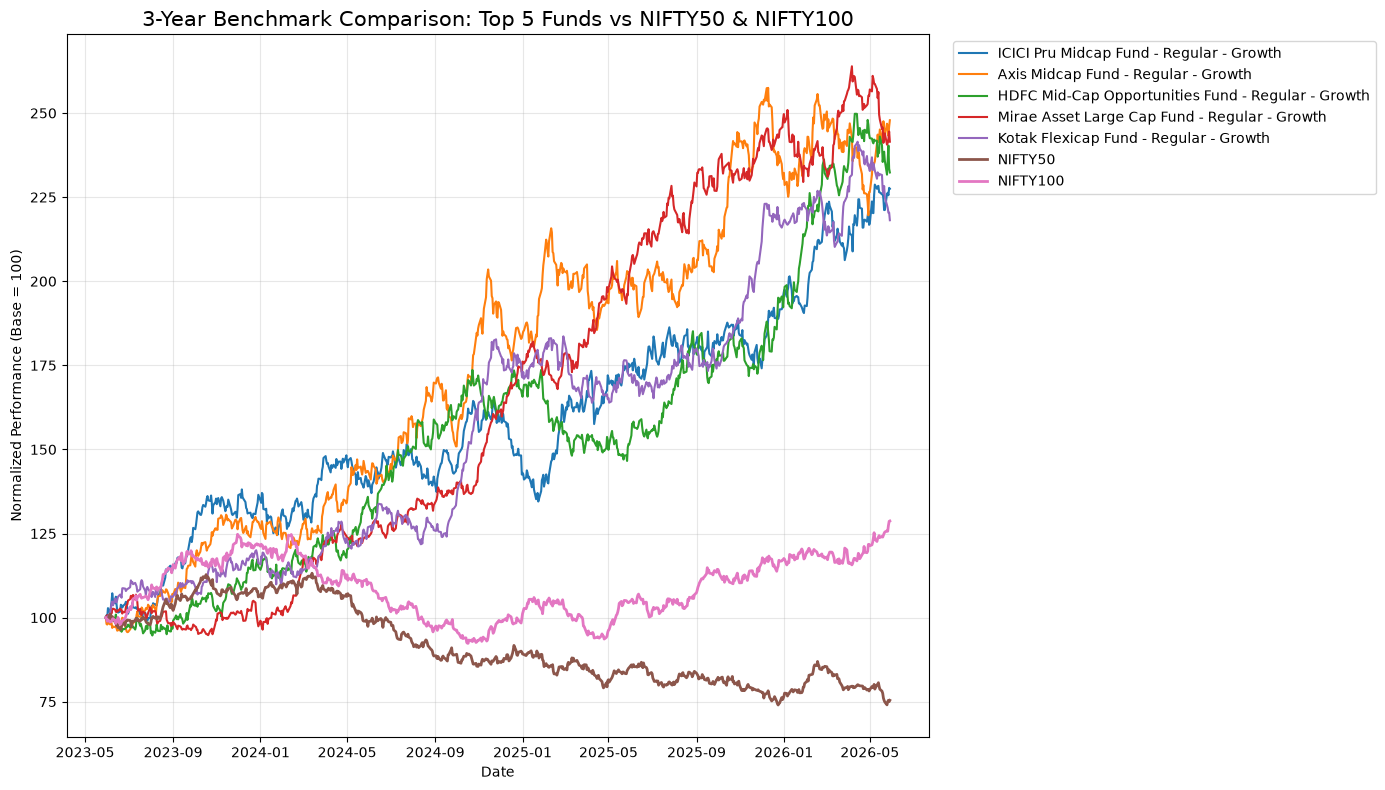

Chart saved successfully:
../reports/charts/benchmark_chart.png


In [ ]:
# -----------------------------------------
# Benchmark Comparison Chart
# Top 5 Funds vs NIFTY50 & NIFTY100
# 3-Year Period
# -----------------------------------------

# Create fund NAV pivot table
fund_nav = nav_top5.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Create benchmark price pivot table
benchmark_prices = benchmark_selected.pivot(
    index="date",
    columns="index_name",
    values="close_value"
)

# Combine fund and benchmark data
comparison = pd.concat(
    [fund_nav, benchmark_prices],
    axis=1
)

# Sort by date
comparison = comparison.sort_index()

# Keep only dates where all Top 5 funds and both benchmarks
comparison = comparison.dropna()

# Normalize all series to 100
normalized = (
    comparison / comparison.iloc[0]
) * 100


plt.figure(figsize=(14, 8))

# Plot Top 5 funds
for code in top5_codes:
    plt.plot(
        normalized.index,
        normalized[code],
        label=fund_names[code]
    )

# Plot NIFTY50
plt.plot(
    normalized.index,
    normalized["NIFTY50"],
    label="NIFTY50",
    linewidth=2
)

# Plot NIFTY100
plt.plot(
    normalized.index,
    normalized["NIFTY100"],
    label="NIFTY100",
    linewidth=2
)


plt.title(
    "3-Year Benchmark Comparison: Top 5 Funds vs NIFTY50 & NIFTY100",
    fontsize=15
)

plt.xlabel("Date")
plt.ylabel("Normalized Performance (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


output_path = "../reports/charts/benchmark_chart.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully:")
print(output_path)